# 통계 분석 — 다중공선성

`260526_preprocessing` 산출물을 사용하여 **당뇨병전단계 → 당뇨병**, **정상 → 당뇨병전단계** 두 데이터셋의 다중공선성(VIF, 상관계수)을 확인합니다.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from core.multicollinearity_analyzer import MulticollinearityAnalyzer

OUTPUT_DIR = Path("../outputs/260527_statistic_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "pre_diabetes": Path("../outputs/260526_preprocessing/pre_diabetes_dataset.xlsx"),
    "diabetes": Path("../outputs/260526_preprocessing/diabetes_dataset.xlsx"),
}

EXCLUDE_COLUMNS = {
    "user_key",
    "current_checkup_date",
    "future_checkup_date",
    "selected_transition",
    "full_transition",
    "interval_days",
    "checkup_date",
}

## 1. 다중공선성 분석

- **y**: `label`
- **제외 컬럼**: 위 셀의 `EXCLUDE_COLUMNS`에서 설정
- **범주형(텍스트) 컬럼**: 원-핫 인코딩 (유목 2개 → 더미 1개, 3개 이상 → `drop_first`)
- **VIF ≥ 10**, **|r| ≥ 0.8** 을 고다중공선성 기준으로 사용

=== pre_diabetes ===


,sample_count,feature_count,vif_threshold,high_vif_count,max_vif,correlation_threshold,high_correlation_pair_count
0,3113,57,10.0,40,9191.145,0.8,5


피처 수: 57, 표본 수: 3,113

[VIF Top 10]


,feature,vif,high_vif
0,SG,9191.145,True
1,MCHC,6799.345,True
2,MCV,6716.104,True
3,MCH,6696.850,True
4,T.Protein,4988.840,True
5,Albumin,2019.375,True
6,신장,1533.944,True
7,RBC,1144.930,True
8,Hct,1108.510,True
9,Hgb,1021.845,True



[고상관 쌍 Top 10]


,feature_a,feature_b,correlation
0,Hct,Hgb,0.876
1,LDL,T.Cholesterol,0.865
2,체중,허리둘레,0.849
3,Hct,RBC,0.831
4,MCH,MCV,0.808


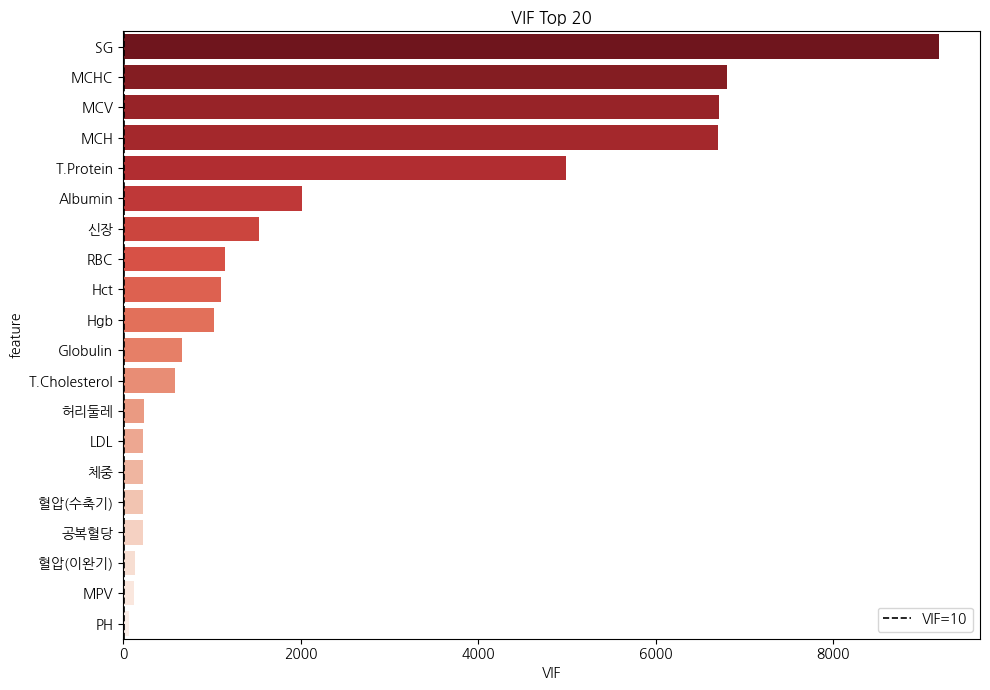

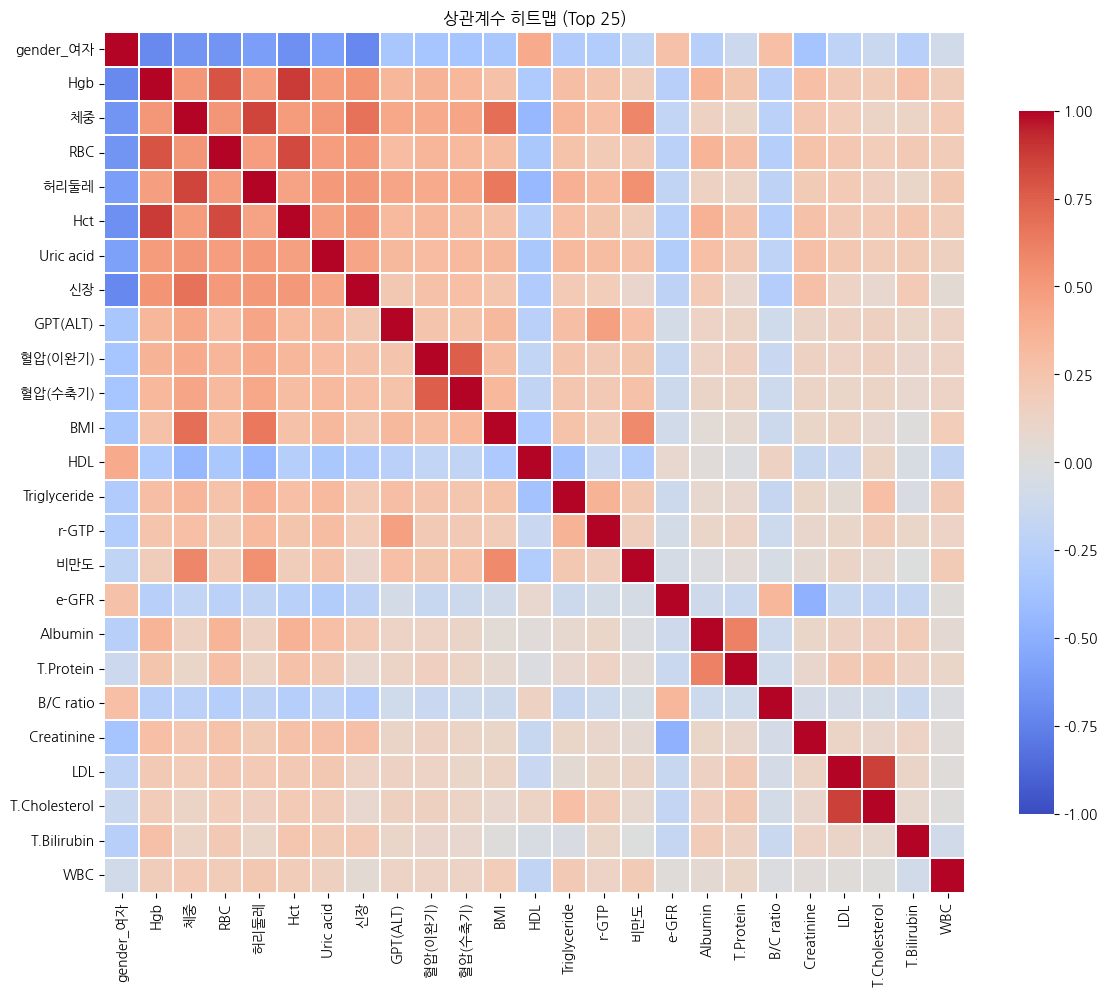


=== diabetes ===


,sample_count,feature_count,vif_threshold,high_vif_count,max_vif,correlation_threshold,high_correlation_pair_count
0,1458,55,10.0,42,8463.496,0.8,5


피처 수: 55, 표본 수: 1,458

[VIF Top 10]


,feature,vif,high_vif
0,SG,8463.496,True
1,T.Protein,5999.439,True
2,Albumin,2687.368,True
3,MCHC,2302.400,True
4,신장,2180.844,True
5,Hgb,1806.457,True
6,RBC,1578.991,True
7,Hct,1251.238,True
8,T.Cholesterol,1233.944,True
9,MCV,1233.689,True



[고상관 쌍 Top 10]


,feature_a,feature_b,correlation
0,LDL,T.Cholesterol,0.875
1,Hct,Hgb,0.869
2,체중,허리둘레,0.843
3,GOT(AST),GPT(ALT),0.833
4,Creatinine,e-GFR,-0.830


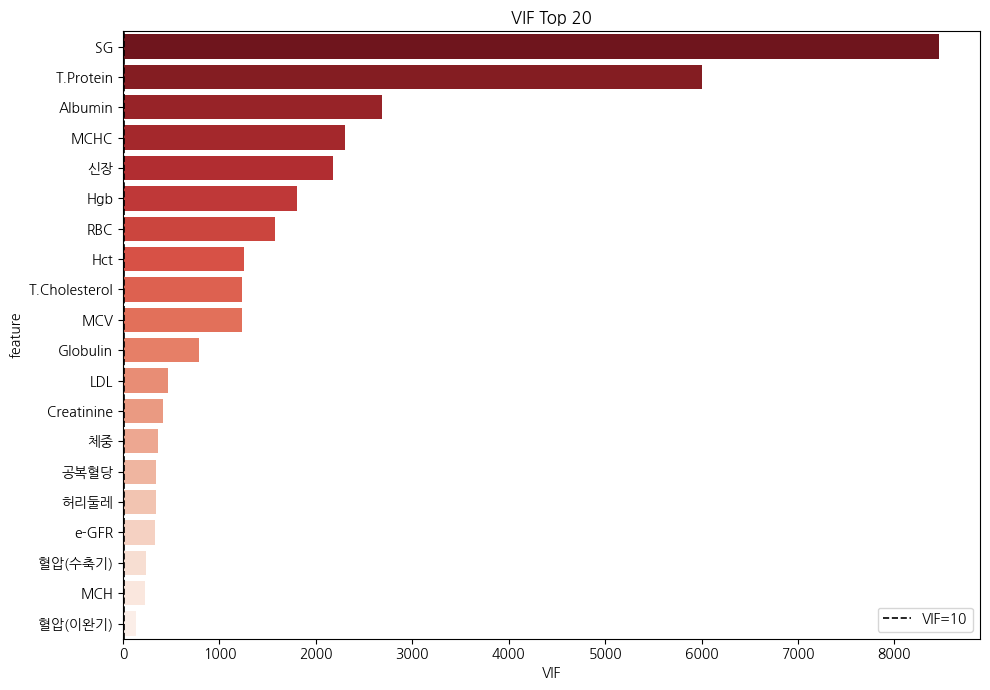

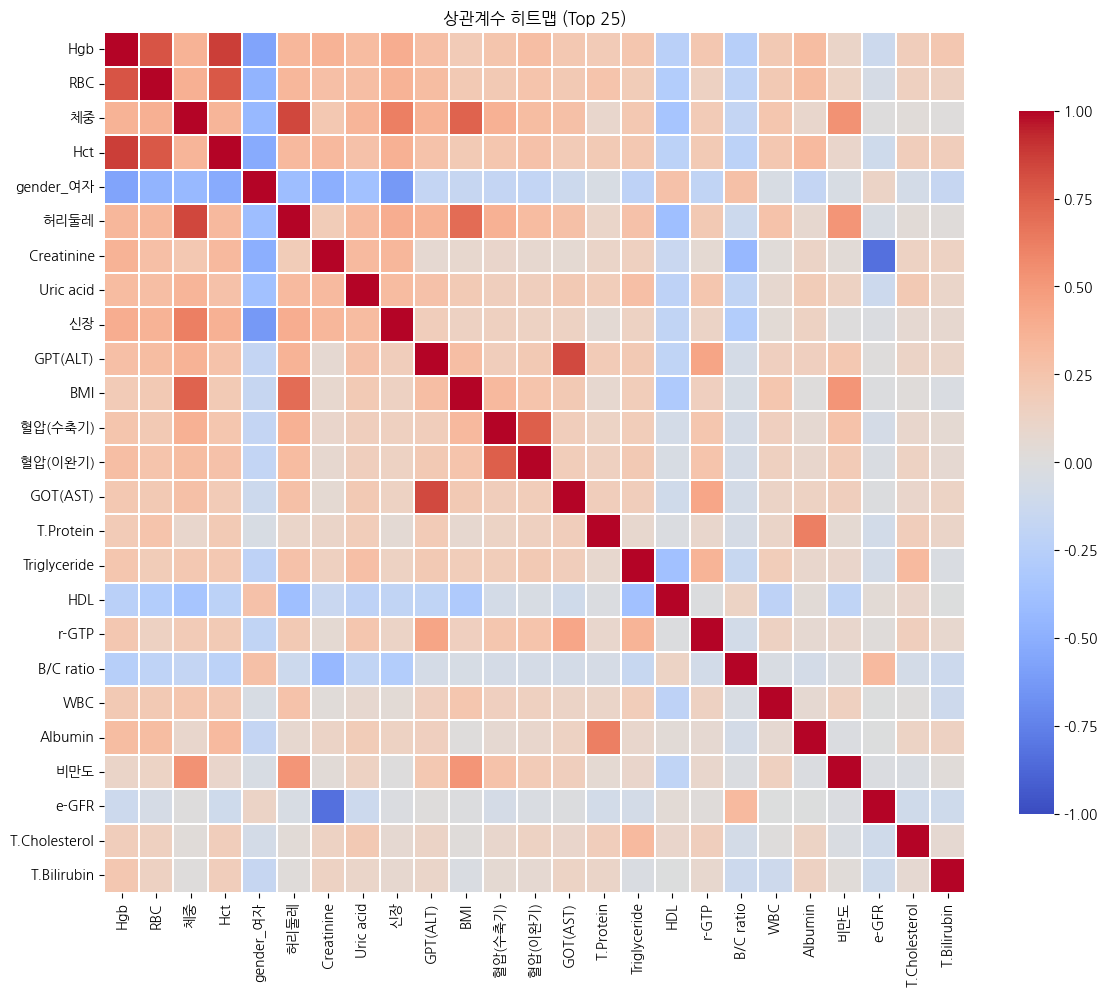

In [2]:
analyzers: dict[str, MulticollinearityAnalyzer] = {}

for name, path in DATASETS.items():
    df = pd.read_excel(path)
    analyzer = MulticollinearityAnalyzer(df, exclude_columns=EXCLUDE_COLUMNS)
    analyzers[name] = analyzer

    dataset_dir = OUTPUT_DIR / name
    analyzer.save_tables(dataset_dir)

    print(f"=== {name} ===")
    display(analyzer.summary())
    print(f"피처 수: {analyzer.feature_count:,}, 표본 수: {analyzer.sample_count:,}")
    print("\n[VIF Top 10]")
    display(analyzer.compute_vif().head(10))
    print("\n[고상관 쌍 Top 10]")
    display(analyzer.high_correlation_pairs().head(10))
    analyzer.plot_vif(dataset_dir / "vif_top20.png", top_n=20, show=True)
    analyzer.plot_correlation_heatmap(
        dataset_dir / "correlation_heatmap_top25.png",
        top_n=25,
        show=True,
    )
    print()

## 2. Iterative VIF Elimination

VIF ≥ 임계값인 피처 중 **가장 VIF가 높은 것을 한 번에 하나씩 제거**하고, 모든 피처의 VIF가 임계값 미만이 될 때까지 반복합니다.

- `PROTECTED_COLUMNS`: VIF가 높더라도 제거하지 않을 피처 (임상적으로 반드시 필요한 변수)

In [3]:
VIF_THRESHOLD = 10.0

PROTECTED_COLUMNS = {
    # ── 당뇨 전이 1차 진단 기준 ──────────────────────────────────────
    "공복혈당",          # 공복혈당 126 mg/dL 이상 = 당뇨 진단 핵심 지표

    # ── 대사증후군 5대 구성 요소 ─────────────────────────────────────
    "BMI",              # 복부비만 대리 지표 (체형 변수 군 대표)
    "혈압(수축기)",       # 고혈압 기준 (130 mmHg 이상)
    "HDL",              # 저HDL: 남 <40, 여 <50 mg/dL → 대사증후군 기준
    "Triglyceride",     # 고중성지방(≥150 mg/dL) → 인슐린 저항성 직결

    # ── 지질 대사 ────────────────────────────────────────────────────
    "LDL",              # LDL 상승 = 심혈관 위험·당뇨 동반 이환 지표

    # ── 간 기능 / 인슐린 저항성 ─────────────────────────────────────
    "GPT(ALT)",         # NAFLD(비알코올 지방간) 지표; 인슐린 저항성과 강한 연관
    "r-GTP",            # 음주·지방간 지표; 당뇨 위험과 독립적으로 연관

    # ── 신장 기능 ────────────────────────────────────────────────────
    "Creatinine",       # 신장 기능 원측정값 (e-GFR의 입력값)

    # ── 요산 / 염증 ──────────────────────────────────────────────────
    "Uric acid",        # 고요산혈증 = 인슐린 저항성·대사증후군 독립 마커
    "WBC",              # 만성 저강도 염증 지표; 당뇨 위험과 연관

    # ── 인구통계 ────────────────────────────────────────────────────
    "나이",              # 나이 증가 = 당뇨 위험 상승 (가장 강한 비수정 위험 요인)
    "gender_여자",       # 성별(여성): 임신성 당뇨·호르몬 변화 등 독립적 위험
}

for name, path in DATASETS.items():
    df = pd.read_excel(path)
    analyzer = MulticollinearityAnalyzer(df, exclude_columns=EXCLUDE_COLUMNS, vif_threshold=VIF_THRESHOLD)
    dataset_dir = OUTPUT_DIR / name

    print(f"=== {name} — Iterative VIF Elimination (threshold={VIF_THRESHOLD}) ===")
    dropped_log = analyzer.iterative_vif_elimination(protected_columns=PROTECTED_COLUMNS)
    result = analyzer.elimination_result()

    print(f"\n[제거된 피처] {len(dropped_log)}개")
    display(dropped_log)

    print(f"\n[생존 피처] {len(result['survived_columns'])}개  |  max VIF = {result['survived']['final_vif'].max():.3f}")
    display(result["survived"])

    analyzer.save_tables(dataset_dir)
    print(f"\n저장 완료: {dataset_dir}\n")

=== pre_diabetes — Iterative VIF Elimination (threshold=10.0) ===

[제거된 피처] 29개


,step,dropped_feature,vif_at_removal,protected
0,1,SG,9191.145,False
1,2,T.Protein,4987.708,False
2,3,MCH,4403.220,False
3,4,MCHC,1280.805,False
4,5,신장,1007.793,False
5,6,Hct,865.320,False
6,7,T.Cholesterol,582.925,False
7,8,MCV,544.954,False
8,9,Hgb,342.701,False
9,10,Albumin,270.916,False



[생존 피처] 28개  |  max VIF = 124.547


,survived_feature,final_vif
0,공복혈당,124.547
1,혈압(수축기),102.064
2,BMI,36.296
3,Uric acid,27.651
4,나이,22.361
5,HDL,19.704
6,LDL,16.324
7,WBC,16.247
8,PDW,7.891
9,Protein_음성,7.714



저장 완료: ../outputs/260527_statistic_analysis/pre_diabetes

=== diabetes — Iterative VIF Elimination (threshold=10.0) ===

[제거된 피처] 31개


,step,dropped_feature,vif_at_removal,protected
0,1,SG,8463.496,False
1,2,T.Protein,5995.404,False
2,3,신장,1845.681,False
3,4,MCHC,1419.909,False
4,5,T.Cholesterol,1225.605,False
5,6,RBC,1071.292,False
6,7,Hct,726.287,False
7,8,MCV,373.896,False
8,9,허리둘레,320.499,False
9,10,Albumin,312.729,False



[생존 피처] 24개  |  max VIF = 165.504


,survived_feature,final_vif
0,공복혈당,165.504
1,혈압(수축기),101.314
2,BMI,46.384
3,Creatinine,44.325
4,Uric acid,30.469
5,나이,24.179
6,HDL,23.134
7,WBC,19.000
8,LDL,13.566
9,Protein_음성,6.857



저장 완료: ../outputs/260527_statistic_analysis/diabetes



## 3. 단변량 로지스틱 회귀 분석 (Univariate Logistic Regression)

다중공선성 분석에서 생존한 피처들을 대상으로, 각각 독립적으로 로지스틱 회귀 분석을 수행합니다.
- **X**: 생존한 각 피처 (단일 변수)
- **y**: `label`
- **출력**: Odds Ratio (OR), 95% 신뢰구간, p-value (OR 기준 내림차순 정렬)

In [4]:
from core.univariate_analyzer import UnivariateLogisticAnalyzer

for name, path in DATASETS.items():
    df = pd.read_excel(path)
    analyzer = MulticollinearityAnalyzer(df, exclude_columns=EXCLUDE_COLUMNS, vif_threshold=VIF_THRESHOLD)
    analyzer.iterative_vif_elimination(protected_columns=PROTECTED_COLUMNS)
    result = analyzer.elimination_result()
    
    survived_cols = result["survived_columns"]
    X_survived = analyzer._feature_df[survived_cols]
    y = analyzer._y
    
    print(f"=== {name} 단변량 로지스틱 회귀 분석 ===")
    uni_analyzer = UnivariateLogisticAnalyzer(X_survived, y)
    or_df = uni_analyzer.analyze()
    
    display(or_df)
    
    dataset_dir = OUTPUT_DIR / name
    dataset_dir.mkdir(parents=True, exist_ok=True)
    or_df.to_csv(dataset_dir / "univariate_or.csv", index=False)
    print(f"저장 완료: {dataset_dir / 'univariate_or.csv'}\n")


=== pre_diabetes 단변량 로지스틱 회귀 분석 ===


,Feature,OR,95% CI Lower,95% CI Upper,p-value,Significance
0,D.Bilirubin,3.354,1.710,6.582,0.0004,True
1,Creatinine,1.886,1.265,2.811,0.0019,True
2,Uric acid,1.336,1.259,1.417,0.0000,True
3,Blood_음성,1.209,0.972,1.504,0.0878,False
4,WBC,1.117,1.061,1.177,0.0000,True
5,HBs-Ag_음성,1.116,0.893,1.393,0.3344,False
6,공복혈당,1.094,1.076,1.111,0.0000,True
7,Leukocyte_음성,1.063,0.862,1.311,0.5692,False
8,BMI,1.061,1.039,1.084,0.0000,True
9,혈압(수축기),1.030,1.023,1.037,0.0000,True


저장 완료: ../outputs/260527_statistic_analysis/pre_diabetes/univariate_or.csv

=== diabetes 단변량 로지스틱 회귀 분석 ===


,Feature,OR,95% CI Lower,95% CI Upper,p-value,Significance
0,D.Bilirubin,3.885,0.872,17.298,0.0749,False
1,WBC,1.295,1.134,1.480,0.0001,True
2,공복혈당,1.171,1.132,1.212,0.0000,True
3,gender_여자,1.151,0.621,2.136,0.6548,False
4,Blood_음성,1.113,0.590,2.101,0.7414,False
5,나이,1.046,1.021,1.072,0.0003,True
6,BMI,1.044,1.006,1.084,0.0241,True
7,혈압(수축기),1.017,1.000,1.034,0.0487,True
8,Protein_음성,1.017,0.526,1.966,0.9596,False
9,PDW,1.014,0.981,1.047,0.4105,False


저장 완료: ../outputs/260527_statistic_analysis/diabetes/univariate_or.csv

